### Workshop the steps in a synthetic reconstruction of narG variants. 

First, build two faa's, one to be used as a reference, the other to generate raw reads.

In [39]:
import numpy as np
import tqdm
ref_directory = '../data/whole_genomes/K00370_rep.faa'

from Bio import SeqIO
import random

# Read all sequences
records = list(SeqIO.parse(ref_directory, "fasta"))
print(f"Total sequences: {len(records)}")

# Shuffle and split 70/30
random.seed(42) #I'm fixing a seed here
random.shuffle(records) 
split_point = int(0.89 * len(records)) #0.89 makes it so there are exactly 100 spike-in sequences

reference_set = records[:split_point]
spikein_set = records[split_point:]

# Write outputs
SeqIO.write(reference_set, "../out/reconstruction/reference.faa", "fasta")
SeqIO.write(spikein_set, "../out/reconstruction/spikein.faa", "fasta")

print(f"Reference: {len(reference_set)} sequences")
print(f"Spike-in: {len(spikein_set)} sequences")

Total sequences: 906
Reference: 806 sequences
Spike-in: 100 sequences


Generate raw reads

In [ ]:
from Bio import SeqIO
import random

def back_translate(protein_seq):
    """Convert protein sequence to DNA using common codons"""
    codon_table = {
        'A': 'GCT', 'R': 'CGT', 'N': 'AAT', 'D': 'GAT',
        'C': 'TGT', 'Q': 'CAG', 'E': 'GAA', 'G': 'GGT',
        'H': 'CAT', 'I': 'ATT', 'L': 'CTG', 'K': 'AAA',
        'M': 'ATG', 'F': 'TTT', 'P': 'CCT', 'S': 'TCT',
        'T': 'ACT', 'W': 'TGG', 'Y': 'TAT', 'V': 'GTT',
        '*': 'TAA'
    }
    dna_seq = ''
    for aa in protein_seq:
        dna_seq += codon_table.get(aa, 'NNN')  # Use NNN for unknown amino acids
    return dna_seq

def add_sequencing_errors(read, error_rate=0.001):
    """Add simple substitution errors to simulate sequencing errors"""
    bases = ['A', 'T', 'C', 'G']
    result = []
    for base in read:
        if random.random() < error_rate:
            # Choose a different base
            new_base = random.choice([b for b in bases if b != base])
            result.append(new_base)
        else:
            result.append(base)
    return ''.join(result)

def generate_paired_end_reads(dna_sequence, read_length=150, coverage=30, insert_size=300, error_rate=0.001):
    """Generate paired-end reads with proper insert size"""
    reads_r1 = []
    reads_r2 = []
    seq_length = len(dna_sequence)
    
    # Calculate number of read pairs needed
    num_pairs = int((seq_length * coverage) // (2 * read_length))
    
    for _ in range(num_pairs):
        # Random start position for R1
        start_r1 = random.randint(0, seq_length - insert_size)
        end_r1 = start_r1 + read_length
        start_r2 = start_r1 + insert_size - read_length
        
        # Ensure we don't go beyond sequence boundaries
        if start_r2 + read_length <= seq_length:
            read_r1 = dna_sequence[start_r1:end_r1]
            read_r2 = dna_sequence[start_r2:start_r2 + read_length]
            
            # Add seequencing errors
            read_r1 = add_sequencing_errors(read_r1, error_rate = error_rate)
            read_r2 = add_sequencing_errors(read_r2, error_rate = error_rate)
            
            # R2 is reverse complement (simulating actual sequencing)
            read_r2 = reverse_complement(read_r2)
            
            reads_r1.append(read_r1)
            reads_r2.append(read_r2)
    
    return reads_r1, reads_r2

def reverse_complement(seq):
    """Simple reverse complement"""
    comp = {'A': 'T', 'T': 'A', 'G': 'C', 'C': 'G', 'N': 'N'}
    return ''.join(comp.get(base, base) for base in reversed(seq))

# Read spike-in protein sequences
spikein_records = list(SeqIO.parse("../out/reconstruction/spikein.faa", "fasta"))


#Generate many raw reads in a loop
coverage_sweep = np.rint(np.logspace(0,2,10)).astype(int)
error_sweep = [0, 0.001, 0.005]
for cov in coverage_sweep:
    for err in error_sweep:
        # Generate paired-end DNA reads
        all_r1 = []
        all_r2 = []

        for record in spikein_records:
            # Convert protein to DNA first!
            dna_sequence = back_translate(str(record.seq))
            print(f"Converted {record.id}: {len(record.seq)}aa -> {len(dna_sequence)}bp DNA")
            
            r1, r2 = generate_paired_end_reads(dna_sequence, read_length=150, coverage = cov, error_rate = err)
            all_r1.extend(r1)
            all_r2.extend(r2)

        print(f"Generated {len(all_r1)} DNA read pairs")

        # Write R1 and R2 files as FASTA
        with open(f"../out/reconstruction/raw_reads/spikein_R1_{cov:.0f}_{err:.3f}.fasta", "w") as f1, \
            open(f"../out/reconstruction/raw_reads/spikein_R2_{cov:.0f}_{err:.3f}.fasta", "w") as f2:
            
            for i, (read1, read2) in enumerate(zip(all_r1, all_r2)):
                # R1 file - FASTA format
                f1.write(f">read_{i}/1\n")
                f1.write(f"{read1}\n")
                
                # R2 file - FASTA format  
                f2.write(f">read_{i}/2\n")
                f2.write(f"{read2}\n")

        print("Paired-end DNA reads written to:")
        print(f"  ../out/reconstruction/raw_reads/spikein_R1_{cov:.0f}_{err:.3f}.fasta")
        print(f"  ../out/reconstruction/raw_reads/spikein_R2_{cov:.0f}_{err:.3f}.fasta")

Converted mdf:K0O62_09975: 1226aa -> 3678bp DNA
Converted bsav:WS86_24840: 1278aa -> 3834bp DNA
Converted cros:N8J89_25570: 1230aa -> 3690bp DNA
Converted dkn:NHB83_00935: 1257aa -> 3771bp DNA
Converted shl:Shal_3440: 1249aa -> 3747bp DNA
Converted sdur:M4V62_16460: 1223aa -> 3669bp DNA
Converted kfv:AS188_05640: 1243aa -> 3729bp DNA
Converted hhi:HAH_4416: 1064aa -> 3192bp DNA
Converted amax:ABWH92_15145: 1250aa -> 3750bp DNA
Converted cry:B7495_16060: 1265aa -> 3795bp DNA
Converted pol:Bpro_4595: 1296aa -> 3888bp DNA
Converted dav:DESACE_06600: 321aa -> 963bp DNA
Converted dml:Dmul_36400: 1230aa -> 3690bp DNA
Converted chic:N8I74_02175: 1241aa -> 3723bp DNA
Converted dve:DESUT3_15870: 1207aa -> 3621bp DNA
Converted snq:CP978_33905: 1242aa -> 3726bp DNA
Converted lwi:UE46_11980: 1224aa -> 3672bp DNA
Converted cwo:Cwoe_1491: 1248aa -> 3744bp DNA
Converted jcy:M6B22_08035: 1236aa -> 3708bp DNA
Converted shai:LMH63_08640: 1250aa -> 3750bp DNA
Converted hpel:HZS54_15595: 1060aa -> 3180bp 

### Then we moved to QUEST to generate contigs and ORFs from these raw reads. 

Analysis of those results is below. 

In [26]:
from Bio import SeqIO
from Bio.Align import PairwiseAligner
import numpy as np

def assess_reconstruction(spikein_faa, prodigal_faa, identity_threshold=0.95):
    """
    Assess how many spike-in variants were successfully reconstructed
    """
    # Load sequences
    spikein_seqs = {rec.id: str(rec.seq) for rec in SeqIO.parse(spikein_faa, "fasta")}
    prodigal_seqs = {rec.id: str(rec.seq) for rec in SeqIO.parse(prodigal_faa, "fasta")}
    
    # Calculate mean spike-in length for faux detection
    spikein_lengths = [len(seq) for seq in spikein_seqs.values()]
    mean_spikein_length = np.mean(spikein_lengths)
    length_threshold = 100  # bp
    
    print(f"=== Reconstruction Assessment ===")
    print(f"Spike-in variants: {len(spikein_seqs)}")
    print(f"Reconstructed ORFs: {len(prodigal_seqs)}")
    print(f"Mean spike-in length: {mean_spikein_length:.0f} aa")
    
    # Simple alignment setup
    aligner = PairwiseAligner()
    aligner.mode = 'global'
    aligner.match_score = 2
    aligner.mismatch_score = -1
    aligner.open_gap_score = -0.5
    aligner.extend_gap_score = -0.1
    
    # Track matches
    reconstructed_variants = set()
    reconstruction_details = []
    faux_orfs = []
    
    # For each spike-in variant, find best match in reconstructed ORFs
    for spike_id, spike_seq in spikein_seqs.items():
        best_match_id = None
        best_identity = 0
        
        for orf_id, orf_seq in prodigal_seqs.items():
            # Quick length filter
            if abs(len(spike_seq) - len(orf_seq)) > 100:  # Allow some length variation
                continue
                
            alignment = aligner.align(spike_seq, orf_seq)[0]
            identity = alignment.score / max(len(spike_seq), len(orf_seq))
            
            if identity > best_identity:
                best_identity = identity
                best_match_id = orf_id
        
        if best_identity >= identity_threshold:
            reconstructed_variants.add(spike_id)
            status = "RECONSTRUCTED"
        else:
            status = "MISSING"
            
        reconstruction_details.append({
            'spike_id': spike_id,
            'best_match': best_match_id,
            'identity': best_identity,
            'status': status
        })
    
    # Identify faux ORFs (full-length but no match to any spike-in)
    full_length_orfs = []
    for orf_id, orf_seq in prodigal_seqs.items():
        orf_length = len(orf_seq)
        # Check if ORF is full-length (within 100bp of mean spike-in length)
        if abs(orf_length - mean_spikein_length) <= length_threshold:
            full_length_orfs.append(orf_id)
            
            # Check if this ORF matches any spike-in above threshold
            matches_any = False
            for spike_seq in spikein_seqs.values():
                if abs(len(spike_seq) - orf_length) > 100:
                    continue
                alignment = aligner.align(spike_seq, orf_seq)[0]
                identity = alignment.score / max(len(spike_seq), orf_length)
                if identity >= identity_threshold:
                    matches_any = True
                    break
            
            if not matches_any:
                faux_orfs.append(orf_id)
    
    # Print results
    print(f"\n=== Results ===")
    print(f"coverage = {cov:.0f}, error rate = {err:.3f}")
    print(f"Successfully reconstructed: {len(reconstructed_variants)}/{len(spikein_seqs)} variants")
    print(f"Reconstruction rate: {len(reconstructed_variants)/len(spikein_seqs)*100:.1f}%")
    print(f"Full-length ORFs: {len(full_length_orfs)}/{len(prodigal_seqs)}")
    print(f"Faux variants: {len(faux_orfs)}/{len(full_length_orfs)}")
    print(f"Faux variant rate: {len(faux_orfs)/len(full_length_orfs)*100:.1f}%" if full_length_orfs else "Faux variant rate: N/A")
    
    # Show details
    # print(f"\n=== Reconstruction Details ===")
    # for detail in sorted(reconstruction_details, key=lambda x: x['identity'], reverse=True):
    #     print(f"{detail['spike_id']} -> {detail['best_match']}: {detail['identity']:.3f} ({detail['status']})")
    
    rates = [
    len(reconstructed_variants) / len(spikein_seqs),
    1 if len(full_length_orfs) == 0 else len(faux_orfs) / len(full_length_orfs)
    ]
    
    numbers = [len(full_length_orfs), len(reconstructed_variants), len(faux_orfs), ]
    # could also return reconstruction_details, faux_orfs
    return rates, numbers



# Run the assessment
rates, numbers = assess_reconstruction(
    spikein_faa="../out/reconstruction/spikein.faa",
    prodigal_faa="../out/reconstruction/prodigal_orfs.faa", 
    identity_threshold=0.95  
)

=== Reconstruction Assessment ===
Spike-in variants: 100
Reconstructed ORFs: 303
Mean spike-in length: 1219 aa

=== Results ===
coverage = 26, error rate = 0.000
Successfully reconstructed: 70/100 variants
Reconstruction rate: 70.0%
Full-length ORFs: 16/303
Faux variants: 3/16
Faux variant rate: 18.8%


In [15]:
print(rates)

[0.7, 18.75]


In [27]:
coverage_sweep_int = [5, 16, 26, 37, 47, 58, 68, 79, 89, 100]

performance_95id = np.zeros((len(coverage_sweep), len(error_sweep), 2))
numbers_95id = np.zeros((len(coverage_sweep), len(error_sweep), 3))

for i in tqdm.trange(len(coverage_sweep)):
    for j in tqdm.trange(len(error_sweep)):
        
        cov = coverage_sweep_int[i]
        err = error_sweep[j]
        
        rates, numbers = assess_reconstruction(
            spikein_faa="../out/reconstruction/spikein.faa",
            prodigal_faa= f"../out/reconstruction/orfs/orfs_{cov:.0f}_{err:.3f}.faa", 
            identity_threshold=0.95)  
            
        performance_95id[i, j] = rates
        numbers_95id[i, j] = numbers
            
        


  0%|          | 0/10 [00:00<?, ?it/s]

=== Reconstruction Assessment ===
Spike-in variants: 100
Reconstructed ORFs: 524
Mean spike-in length: 1219 aa



=== Results ===
coverage = 5, error rate = 0.000
Successfully reconstructed: 5/100 variants
Reconstruction rate: 5.0%
Full-length ORFs: 2/524
Faux variants: 0/2
Faux variant rate: 0.0%
=== Reconstruction Assessment ===
Spike-in variants: 100
Reconstructed ORFs: 483
Mean spike-in length: 1219 aa

=== Results ===
coverage = 5, error rate = 0.001
Successfully reconstructed: 1/100 variants
Reconstruction rate: 1.0%
Full-length ORFs: 0/483
Faux variants: 0/0
Faux variant rate: N/A
=== Reconstruction Assessment ===
Spike-in variants: 100
Reconstructed ORFs: 514
Mean spike-in length: 1219 aa


 10%|█         | 1/10 [00:01<00:14,  1.65s/it]


=== Results ===
coverage = 5, error rate = 0.005
Successfully reconstructed: 2/100 variants
Reconstruction rate: 2.0%
Full-length ORFs: 0/514
Faux variants: 0/0
Faux variant rate: N/A


...

=== Reconstruction Assessment ===
Spike-in variants: 100
Reconstructed ORFs: 202
Mean spike-in length: 1219 aa



=== Results ===
coverage = 100, error rate = 0.000
Successfully reconstructed: 90/100 variants
Reconstruction rate: 90.0%
Full-length ORFs: 37/202
Faux variants: 4/37
Faux variant rate: 10.8%
=== Reconstruction Assessment ===
Spike-in variants: 100
Reconstructed ORFs: 201
Mean spike-in length: 1219 aa



=== Results ===
coverage = 100, error rate = 0.001
Successfully reconstructed: 82/100 variants
Reconstruction rate: 82.0%
Full-length ORFs: 34/201
Faux variants: 4/34
Faux variant rate: 11.8%
=== Reconstruction Assessment ===
Spike-in variants: 100
Reconstructed ORFs: 204
Mean spike-in length: 1219 aa


100%|██████████| 10/10 [10:30<00:00, 63.08s/it]


=== Results ===
coverage = 100, error rate = 0.005
Successfully reconstructed: 91/100 variants
Reconstruction rate: 91.0%
Full-length ORFs: 31/204
Faux variants: 4/31
Faux variant rate: 12.9%


Text(0.5, 0, 'Read Coverage')

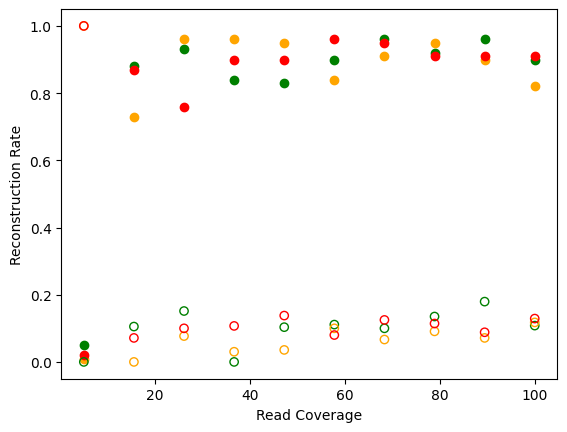

In [38]:
import matplotlib.pyplot as plt

x = np.linspace(5, 100, 10)

plt.scatter(x, performance_95id[:, 0,  0],  color = 'Green')
plt.scatter(x, performance_95id[:, 1,  0],  color = 'Orange')
plt.scatter(x, performance_95id[:, 2,  0],  color = 'Red')
plt.ylabel('Reconstruction Rate')

plt.scatter(x, performance_95id[:, 0,  1],  color = 'Green', facecolors='none')
plt.scatter(x, performance_95id[:, 1,  1],  color = 'Orange', facecolors='none')
plt.scatter(x, performance_95id[:, 2,  1],  color = 'Red', facecolors='none')
plt.xlabel('Read Coverage')



In [46]:
print(np.logspace(0,2,10))
rounded = np.rint(np.logspace(0,2,10)).astype(int)
print(rounded)

[  1.           1.66810054   2.7825594    4.64158883   7.74263683
  12.91549665  21.5443469   35.93813664  59.94842503 100.        ]
[  1   2   3   5   8  13  22  36  60 100]
